---
## Task 1 – Đọc file & Khai phá dữ liệu (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset/tomato-yields.csv')

df.columns = ['Entity', 'Code', 'Year', 'Yield']

print('=== THÔNG TIN CƠ BẢN ===')
print(f'Số dòng x cột : {df.shape}')
print(f'Số quốc gia/vùng : {df["Entity"].nunique()}')
print(f'Khoảng năm      : {df["Year"].min()} – {df["Year"].max()}')
print()
print('=== KIỂU DỮ LIỆU ===')
print(df.dtypes)
print()
print('=== 5 DÒNG ĐẦU ===')
df.head()

=== THÔNG TIN CƠ BẢN ===
Số dòng x cột : (11282, 4)
Số quốc gia/vùng : 220
Khoảng năm      : 1961 – 2020

=== KIỂU DỮ LIỆU ===
Entity     object
Code       object
Year        int64
Yield     float64
dtype: object

=== 5 DÒNG ĐẦU ===


,Entity,Code,Year,Yield
0,Africa,NaN,1961,12.320172
1,Africa,NaN,1962,12.976988
2,Africa,NaN,1963,12.867894
3,Africa,NaN,1964,13.189582
4,Africa,NaN,1965,13.492712


In [9]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': missing_pct}))
print()


        Số lượng  Tỷ lệ (%)
Entity         0       0.00
Code        2489      22.06
Year           0       0.00
Yield          0       0.00



In [ ]:

COUNTRIES = ['United States', 'Spain', 'China', 'India']
df4 = df[df['Entity'].isin(COUNTRIES)].copy()

stats = df4.groupby('Entity')['Yield'].agg(
    Năm_đầu=lambda x: x.iloc[0],
    Năm_cuối=lambda x: x.iloc[-1],
    Min='min',
    Max='max',
    Trung_bình='mean',
    Độ_lệch_chuẩn='std'
).round(2)

stats['Tăng_trưởng (%)'] = ((stats['Năm_cuối'] - stats['Năm_đầu']) / stats['Năm_đầu'] * 100).round(1)
stats = stats.sort_values('Năm_cuối', ascending=False)
print('=== THỐNG KÊ 4 QUỐC GIA (1961–2020) ===')
stats

=== THỐNG KÊ 4 QUỐC GIA (1961–2020) ===


,Năm_đầu,Năm_cuối,Min,Max,Trung_bình,Độ_lệch_chuẩn,Tăng_trưởng (%)
Entity,,,,,,,
United States,25.45,110.72,25.45,110.72,59.48,23.36,335.0
Spain,22.19,77.75,22.19,89.29,50.27,21.35,250.4
China,16.00,58.48,16.00,58.48,31.05,12.77,265.5
India,9.28,25.34,8.13,25.98,14.15,5.25,173.1


---
## Task 2 – Biểu đồ đường: năng suất qua các năm

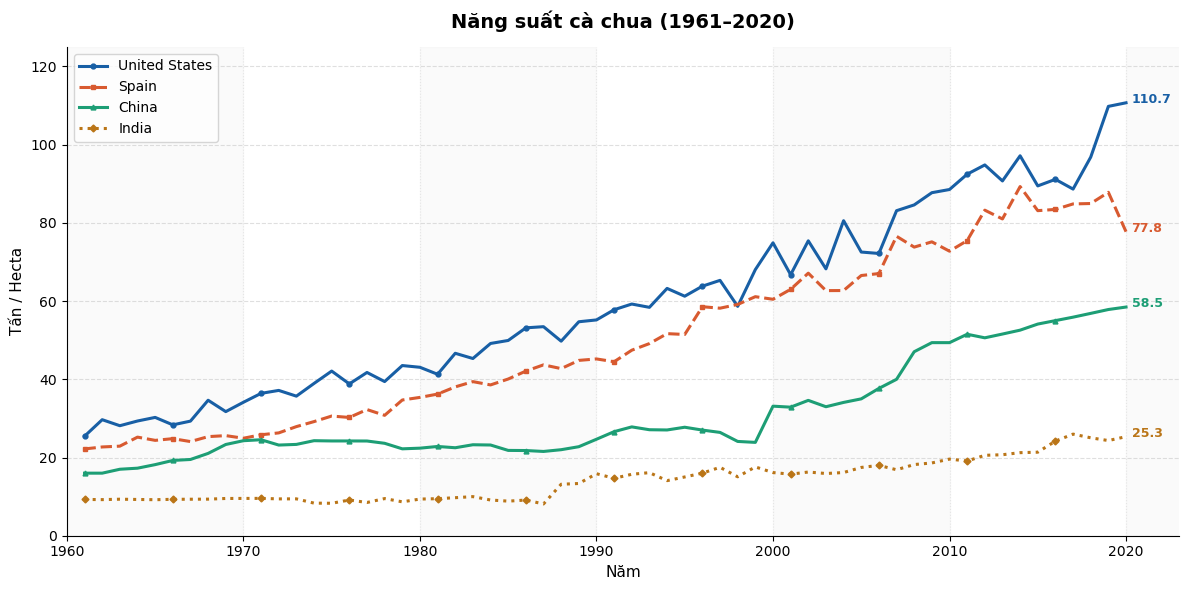

Đã lưu: tomato_yield_line_chart.png


In [ ]:

STYLE = {
    'United States': {'color': '#185FA5', 'linestyle': '-',  'marker': 'o', 'label': 'United States'},
    'Spain':         {'color': '#D85A30', 'linestyle': '--', 'marker': 's', 'label': 'Spain'},
    'China':         {'color': '#1D9E75', 'linestyle': '-',  'marker': '^', 'label': 'China'},
    'India':         {'color': '#BA7517', 'linestyle': ':',  'marker': 'D', 'label': 'India'},
}

fig, ax = plt.subplots(figsize=(12, 6))

for country in COUNTRIES:
    sub = df4[df4['Entity'] == country].sort_values('Year')
    s = STYLE[country]
    ax.plot(
        sub['Year'], sub['Yield'],
        color=s['color'], linestyle=s['linestyle'],
        linewidth=2.2, marker=s['marker'],
        markersize=3.5, markevery=5,      
        label=s['label']
    )
    
    last = sub.iloc[-1]
    ax.annotate(
        f"{last['Yield']:.1f}",
        xy=(last['Year'], last['Yield']),
        xytext=(4, 0), textcoords='offset points',
        fontsize=9, color=s['color'], fontweight='bold'
    )

ax.set_title('Năng suất cà chua (1961–2020)', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Tấn / Hecta', fontsize=11)
ax.set_xlim(1960, 2023)
ax.set_ylim(0, 125)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)
ax.legend(loc='upper left', fontsize=10, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)


for decade in range(1960, 2021, 20):
    ax.axvspan(decade, decade + 10, alpha=0.04, color='gray')

plt.tight_layout()
plt.savefig('tomato_yield_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: tomato_yield_line_chart.png')

---
## Task 3 – Biểu đồ bổ sung: tốc độ tăng trưởng theo thập kỷ

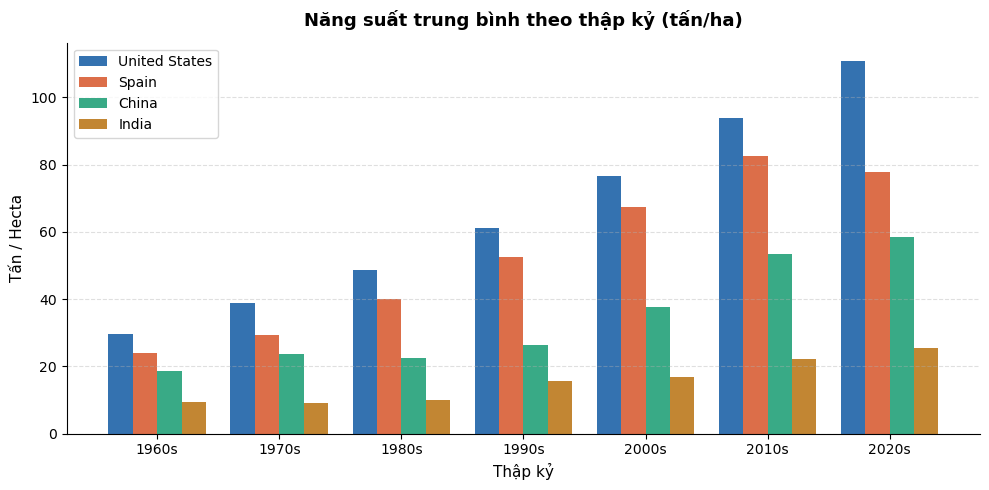

Đã lưu: tomato_yield_decade_bar.png


In [ ]:
df4['Decade'] = (df4['Year'] // 10) * 10
decade_avg = df4.groupby(['Entity', 'Decade'])['Yield'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

DECADES = sorted(decade_avg['Decade'].unique())
x = np.arange(len(DECADES))
width = 0.2

for i, country in enumerate(COUNTRIES):
    vals = [decade_avg[(decade_avg['Entity']==country) & (decade_avg['Decade']==d)]['Yield'].values[0]
            for d in DECADES]
    bars = ax.bar(x + i*width, vals, width=width,
                  color=STYLE[country]['color'], label=country, alpha=0.88)

ax.set_title('Năng suất trung bình theo thập kỷ (tấn/ha)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Thập kỷ', fontsize=11)
ax.set_ylabel('Tấn / Hecta', fontsize=11)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{d}s" for d in DECADES], fontsize=10)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('tomato_yield_decade_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: tomato_yield_decade_bar.png')

---
## Task 3 – Nhận xét phân tích

### 1. Xu hướng chung
Tất cả 4 quốc gia đều có **xu hướng tăng liên tục** từ 1961 đến 2020, phản ánh tiến bộ về giống cây, phân bón, tưới tiêu và cơ giới hóa nông nghiệp. Không có quốc gia nào suy giảm lâu dài.

---

### 2. Từng quốc gia

| Quốc gia | 1961 | 2020 | Tăng | Nhận xét |
|---|---|---|---|---|
| **United States** | 25.5 | 110.7 | +335% | Cao nhất, tăng đều và mạnh nhất |
| **Spain** | 22.2 | 77.8 | +250% | Tăng nhanh từ 1990, gần bằng Mỹ |
| **China** | 16.0 | 58.5 | +265% | Đột phá rõ từ năm 2000 |
| **India** | 9.3 | 25.3 | +172% | Thấp nhất, tăng chậm nhất |

---

### 3. So sánh các quốc gia

- **United States** dẫn đầu xuyên suốt 60 năm. Áp dụng nông nghiệp công nghệ cao (nhà kính, tự động hóa) giúp năng suất vượt 100 tấn/ha vào 2019–2020.

- **Spain** xuất phát điểm tương đương Mỹ nhưng tăng chậm hơn ở giai đoạn 1961–1990. Từ 1990 trở đi, Tây Ban Nha tăng tốc mạnh — nhờ nông nghiệp nhà kính (vùng Almería) — và rút ngắn khoảng cách đáng kể với Mỹ.

- **China** có giai đoạn 1961–1999 tăng rất chậm (dao động quanh 16–25 tấn/ha). Bước ngoặt xảy ra sau năm 2000 khi Trung Quốc đẩy mạnh hiện đại hóa nông nghiệp, năng suất tăng gần gấp đôi chỉ trong 20 năm (2000–2020).

- **India** có năng suất thấp nhất và tăng chậm nhất. Giai đoạn 1961–1986 gần như giậm chân tại chỗ (~9 tấn/ha). Sau 1987 có cải thiện nhưng vẫn còn khoảng cách rất lớn so với 3 nước còn lại, cho thấy tiềm năng tăng trưởng còn nhiều nếu cải thiện hạ tầng nông nghiệp.

### 4. Kết luận
> Khoảng cách giữa nhóm dẫn đầu (Mỹ, Tây Ban Nha) và nhóm đang phát triển (Trung Quốc, Ấn Độ) **đang thu hẹp dần** nhờ chuyển giao công nghệ. Trung Quốc là quốc gia thể hiện sự **bứt phá rõ nét nhất** trong 20 năm gần đây.